# AI/ML Task 2 - House Price Prediction (Model Comparison)

**Intern:** Anik Biswas
**Internship:** Main Crafts Technology - AI/ML Internship
**Task:** Feature Engineering, Model Optimization & Performance Comparison

In Task 1 I loaded a dataset, trained one basic model and checked its accuracy. This task goes a step further - proper preprocessing (feature scaling), training more than one algorithm, and comparing them using actual metrics instead of just eyeballing it.

Dataset: **California Housing Dataset** (from `sklearn.datasets`), target variable is the median house value for a block group.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# just to keep the notebook a bit cleaner
%matplotlib inline
sns.set_style("whitegrid")

## Step 2: Load the Dataset

Using the built-in California housing dataset from scikit-learn (no need to download anything manually).

In [2]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.shape

(20433, 9)

Quick look at data types and whether there's any missing data - Task 1 didn't really check this properly so doing it now.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20433 non-null  float64
 1   HouseAge    20433 non-null  float64
 2   AveRooms    20433 non-null  float64
 3   AveBedrms   20433 non-null  float64
 4   Population  20433 non-null  float64
 5   AveOccup    20433 non-null  float64
 6   Latitude    20433 non-null  float64
 7   Longitude   20433 non-null  float64
 8   HousePrice  20433 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0

No missing values, good - one less thing to deal with. Let's also look at the summary stats.

In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20433.00,20433.00,20433.00,20433.00,20433.00,20433.00,20433.00,20433.00,20433.00
mean,3.87,28.63,5.43,1.10,1424.95,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.48,0.48,1133.21,10.44,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.54,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1722.00,3.28,37.72,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


### A quick correlation check (bonus, not in the original steps but useful)

Before jumping into modeling I wanted to see which features actually correlate with house price - helps sanity-check the results later.

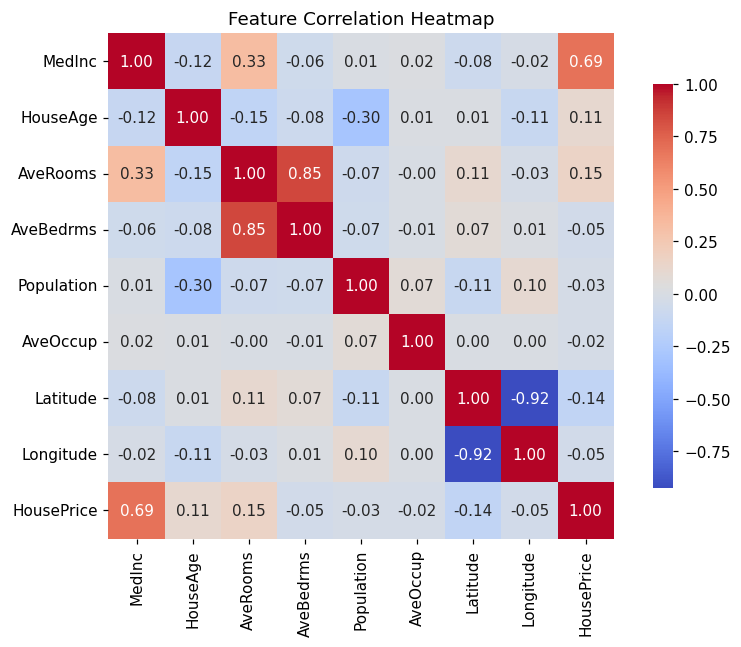

In [7]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

`MedInc` (median income) has by far the strongest correlation with house price, which lines up with common sense - richer areas = pricier houses. `Latitude`/`Longitude` also matter a bit since location affects price a lot in California.

## Step 3: Separate Features and Target Variable

In [8]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20433, 8)
y shape: (20433,)

## Step 4: Feature Scaling (Critical Step)

Features here are on very different scales - e.g. `Population` can be in the thousands while `AveRooms` is a small number. Without scaling, models like Linear/Ridge Regression can get unstable and gradient-based models would basically let the big-range features dominate. `StandardScaler` fixes this by putting everything on a common scale (mean 0, std 1).

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.345,0.982,0.625,-0.154,-0.973,-0.049,1.052,-1.327
1,2.333,-0.606,0.325,-0.263,0.861,-0.092,1.042,-1.322
2,1.783,1.856,1.151,-0.050,-0.820,-0.026,1.038,-1.332
3,0.933,1.856,0.155,-0.050,-0.765,-0.050,1.038,-1.337
4,-0.013,1.856,0.343,-0.034,-0.759,-0.085,1.038,-1.337


## Step 5: Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)

X_train: (16346, 8), X_test: (4087, 8)
y_train: (16346,), y_test: (4087,)

80/20 split, `random_state=42` just so results are reproducible if I re-run this later.

## Step 6: Train Multiple Models

Instead of relying on one algorithm, training three different ones:
- **Linear Regression** - simple baseline, assumes a straight-line relationship
- **Ridge Regression** - same as linear but with L2 regularization, helps if there's any overfitting/multicollinearity
- **Decision Tree Regressor** - can capture non-linear patterns that the linear models can't

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

## Step 7: Model Evaluation and Comparison

Using RMSE (how far off predictions are, in the same units as the target) and R² (how much of the variance in price the model explains).

In [12]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results[name] = {"RMSE": rmse, "R2 Score": r2}

results_df = pd.DataFrame(results).T
results_df

,RMSE,R2 Score
Linear Regression,0.7514,0.5871
Ridge Regression,0.7514,0.5872
Decision Tree,0.7321,0.6080


**Interpretation:**
- Lower RMSE = predictions are closer to actual prices on average
- Higher R² = model explains more of the variation in house prices

The **Decision Tree** came out on top here - lowest RMSE and highest R². Linear and Ridge basically performed the same (makes sense, `alpha=1.0` isn't regularizing very aggressively on this data), while the Decision Tree was able to pick up on some non-linear patterns the two linear models couldn't, which is probably why it edged them out. That said, an R² around 0.6 means there's still a good chunk of price variation these models aren't capturing - things like exact neighborhood/school quality aren't in this dataset at all.

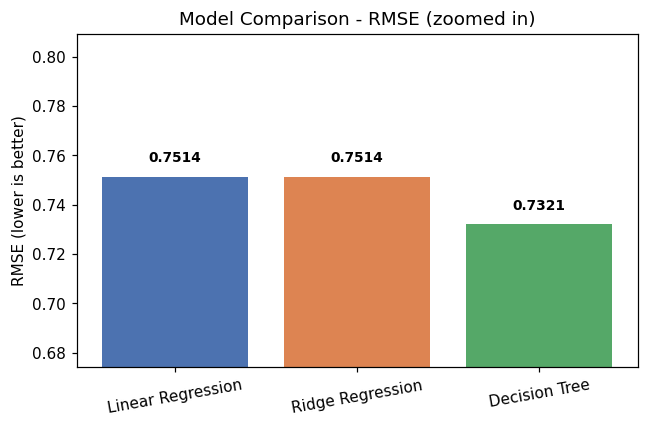

In [13]:
plt.figure(figsize=(6,4))
colors = ["#4C72B0", "#DD8452", "#55A868"]
bars = plt.bar(results_df.index, results_df["RMSE"], color=colors)

# the RMSE values are pretty close to each other (0.73-0.75), so starting
# the y-axis at 0 hides the difference - zooming in instead and labeling
# each bar so the comparison is actually readable
lo, hi = results_df["RMSE"].min(), results_df["RMSE"].max()
pad = (hi - lo) * 3
plt.ylim(lo - pad, hi + pad)

for bar, val in zip(bars, results_df["RMSE"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + pad*0.08,
              f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.ylabel("RMSE (lower is better)")
plt.title("Model Comparison - RMSE (zoomed in)")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## Step 8: Visual Performance Validation

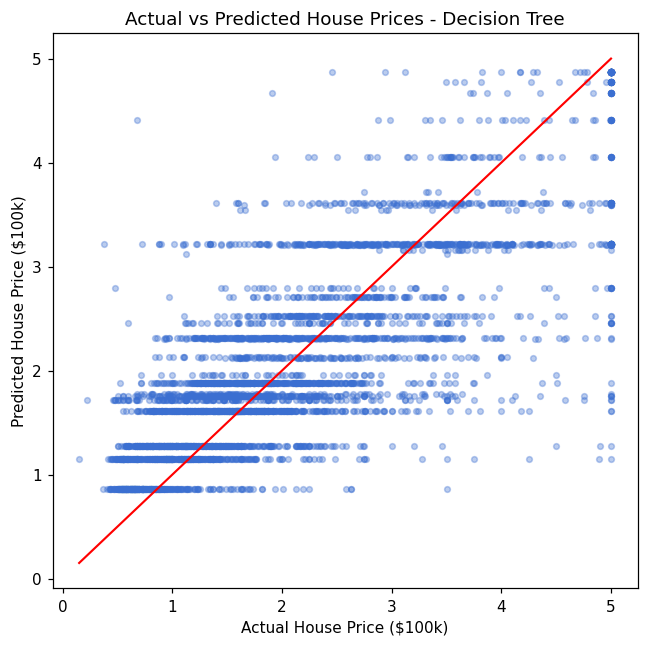

In [14]:
best_model_name = results_df["RMSE"].idxmin()
best_model = models[best_model_name]
preds = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.35, s=14, color="#3b6fd1")
plt.xlabel("Actual House Price ($100k)")
plt.ylabel("Predicted House Price ($100k)")
plt.title(f"Actual vs Predicted House Prices - {best_model_name}")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.tight_layout()
plt.show()

Points closer to the red diagonal = better predictions. There's a visible cluster of underpredicted points near the top - the dataset caps house values at 5.0 ($500k) which the model doesn't know about, so it struggles a bit on the most expensive homes.

### Bonus: what is the Decision Tree actually using?

Since the tree ended up winning, curious which features it's relying on most.

In [15]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances

MedInc        0.772
AveOccup      0.133
HouseAge      0.041
AveRooms      0.031
Latitude      0.020
Population    0.002
AveBedrms     0.001
Longitude     0.000

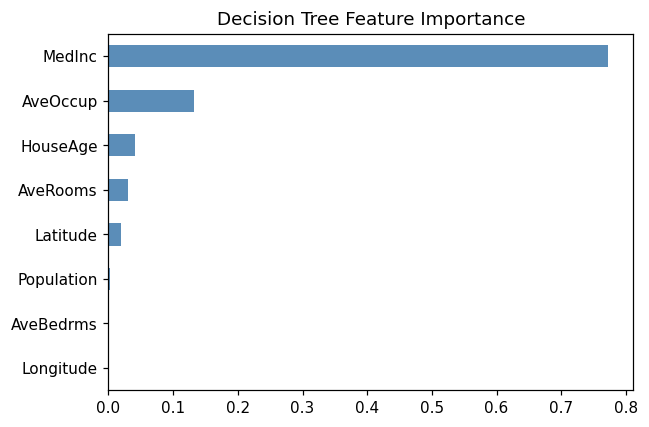

In [16]:
plt.figure(figsize=(6,4))
importances.plot(kind="barh", color="#5B8DB8")
plt.gca().invert_yaxis()
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

Not surprising - `MedInc` dominates, matching the correlation heatmap from earlier.

## Optional: Save the Best Model

Saving the trained model and the scaler so they could be reused later without retraining (e.g. in a small prediction script or API).

In [17]:
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Saved best_model.pkl and scaler.pkl")

Saved best_model.pkl and scaler.pkl


## Summary

- Scaled all features before training since they were on very different ranges
- Trained and compared 3 models: Linear Regression, Ridge Regression, Decision Tree
- **Decision Tree** performed best on this split (lowest RMSE, highest R²)
- Saved the winning model + scaler with `joblib` so it can be loaded again later

Full methodology, results and conclusion are also written up separately in the PDF report.